## # WebSight_70k — статистический анализ датасета

Ноутбук считает по датасету `mrm8488/WebSight_70k` метрики, аналогичные анализу WebCode2M.

Метрики:
1. Количество примеров
2. Количество языков (если присутствует поле lang)
3. Средний размер HTML
4. Среднее количество DOM-узлов
5. Размер скриншота
6. Среднее количество CSS правил
7. Среднее количество уникальных доменов


## 1. Установка зависимостей

In [1]:
%pip install -q datasets lxml pandas matplotlib tqdm huggingface_hub

## 2. Импорты и конфигурация

In [2]:
import os
import re
import logging
from urllib.parse import urlparse

import pandas as pd
import matplotlib.pyplot as plt
from lxml import html as lxml_html
from tqdm.auto import tqdm

HF_TOKEN = os.environ.get("HF_TOKEN")
if HF_TOKEN:
    from huggingface_hub import login
    login(token=HF_TOKEN, add_to_git_credential=False)

import datasets
from datasets import load_dataset

logging.getLogger("httpx").setLevel(logging.WARNING)

DATASET = "mrm8488/WebSight_70k"
SPLIT = "train"
SAMPLE_SIZE = 5000

print(f"datasets: {datasets.__version__}")
print(f"Датасет: {DATASET}, выборка: {SAMPLE_SIZE}")

datasets: 4.0.0
Датасет: mrm8488/WebSight_70k, выборка: 5000


## 3. Метрика 1 — количество примеров

In [3]:
ds_info = load_dataset(DATASET)

TOTAL_EXAMPLES = len(ds_info[SPLIT])

print(f"[Метрика 1] Количество примеров в датасете ({SPLIT}): {TOTAL_EXAMPLES:,}")

README.md:   0%|          | 0.00/443 [00:00<?, ?B/s]

data/train-00000-of-00007.parquet:   0%|          | 0.00/379M [00:00<?, ?B/s]

data/train-00001-of-00007.parquet:   0%|          | 0.00/375M [00:00<?, ?B/s]

data/train-00002-of-00007.parquet:   0%|          | 0.00/379M [00:00<?, ?B/s]

data/train-00003-of-00007.parquet:   0%|          | 0.00/379M [00:00<?, ?B/s]

...

data/test-00000-of-00002.parquet:   0%|          | 0.00/237M [00:00<?, ?B/s]

data/test-00001-of-00002.parquet:   0%|          | 0.00/231M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/69953 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/12345 [00:00<?, ? examples/s]

[Метрика 1] Количество примеров в датасете (train): 69,953


## 4. Загрузка стрим-датасета

In [4]:
dataset = load_dataset(DATASET, streaming=True)
dataset

sample = next(iter(dataset[SPLIT].take(1)))
print(sample.keys())

dict_keys(['image', 'text'])


## 5. Функции-хелперы

In [5]:
def count_dom_nodes(tree):
    return len(tree.xpath(".//*")) + len(tree.xpath("//text()"))

_DECL_RE = re.compile(r"[^{}:;]+:[^{}:;]+")

def _count_declarations(css_body):
    return sum(1 for _ in _DECL_RE.finditer(css_body))

def count_css_declarations(tree):
    total = 0
    for style_attr in tree.xpath("//*/@style"):
        total += _count_declarations(style_attr)

    for style_text in tree.xpath("//style//text()"):
        for block in re.findall(r"\{([^{}]*)\}", style_text):
            total += _count_declarations(block)

    return total

def count_unique_domains(tree):
    domains = set()

    for url in tree.xpath("//@src | //@href | //@data-src"):
        url = (url or "").strip()

        if not url or url.startswith(
            ("#", "mailto:", "tel:", "javascript:", "data:")
        ):
            continue

        parse_target = "http:" + url if url.startswith("//") else url

        netloc = urlparse(parse_target).netloc.lower()

        if netloc:
            domains.add(netloc)

    return len(domains)

## 6. Главный цикл по выборке

In [6]:
records = []

for row in tqdm(dataset[SPLIT].take(SAMPLE_SIZE),
                total=SAMPLE_SIZE,
                desc="Обработка"):

    text = (
        row.get("text")
        or row.get("html")
        or row.get("code")
        or ""
    )

    img = row.get("image")
    img_w, img_h = (
        img.size if img is not None else (None, None)
    )

    lang = row.get("lang", "unknown")

    rec = {
        "html_chars": len(text),
        "html_bytes": len(text.encode("utf-8")),
        "img_w": img_w,
        "img_h": img_h,
        "dom_nodes": None,
        "css_decls": None,
        "n_domains": None,
        "lang": str(lang).lower(),
        "parse_ok": False,
    }

    try:
        tree = lxml_html.fromstring(text)

        rec["dom_nodes"] = count_dom_nodes(tree)
        rec["css_decls"] = count_css_declarations(tree)
        rec["n_domains"] = count_unique_domains(tree)
        rec["parse_ok"] = True

    except Exception:
        pass

    records.append(rec)

print(
    f"Собрано записей: {len(records)}, "
    f"распарсено успешно: "
    f"{sum(r['parse_ok'] for r in records)}"
)

Обработка:   0%|          | 0/5000 [00:00<?, ?it/s]

Собрано записей: 5000, распарсено успешно: 5000


## 7. DataFrame с признаками

In [7]:
df = pd.DataFrame(records)

print(
    f"Размер списка признаков в памяти: "
    f"{df.memory_usage(deep=True).sum()/1024**2:.2f} МБ"
)

df.head()

Размер списка признаков в памяти: 0.54 МБ


,html_chars,html_bytes,img_w,img_h,dom_nodes,css_decls,n_domains,lang,parse_ok
0,833,833,1280,720,35,12,0,unknown,True
1,964,964,1280,720,52,9,0,unknown,True
2,1615,1615,1280,1149,75,26,0,unknown,True
3,1021,1021,1280,720,41,16,0,unknown,True
4,948,948,1280,950,40,12,0,unknown,True


## 8. Агрегированные метрики

In [8]:
ok = df[df["parse_ok"]]

agg = pd.DataFrame({
    "mean": [
        ok["html_chars"].mean(),
        ok["html_bytes"].mean(),
        ok["dom_nodes"].mean(),
        ok["css_decls"].mean(),
        ok["n_domains"].mean(),
        ok["img_h"].mean(),
    ],
    "median": [
        ok["html_chars"].median(),
        ok["html_bytes"].median(),
        ok["dom_nodes"].median(),
        ok["css_decls"].median(),
        ok["n_domains"].median(),
        ok["img_h"].median(),
    ],
}, index=[
    "HTML символов",
    "HTML байт",
    "DOM-узлы",
    "CSS декларации",
    "Уникальные домены",
    "Высота скриншота, px"
])

agg.round(1)

,mean,median
HTML символов,1406.5,1364.5
HTML байт,1407.9,1365.0
DOM-узлы,52.9,51.0
CSS декларации,21.3,21.0
Уникальные домены,0.0,0.0
"Высота скриншота, px",858.8,720.0


## 9. Метрика 2 — количество языков

In [9]:
if "lang" in df.columns:
    lang_counts = df["lang"].value_counts()
    n_langs = df.loc[df["lang"] != "unknown", "lang"].nunique()

    print(f"Уникальных языков: {n_langs}")
    display(lang_counts.head(15))
else:
    print("Поле lang отсутствует")

Уникальных языков: 0


,count
lang,
unknown,5000


## 10. Гистограммы распределений

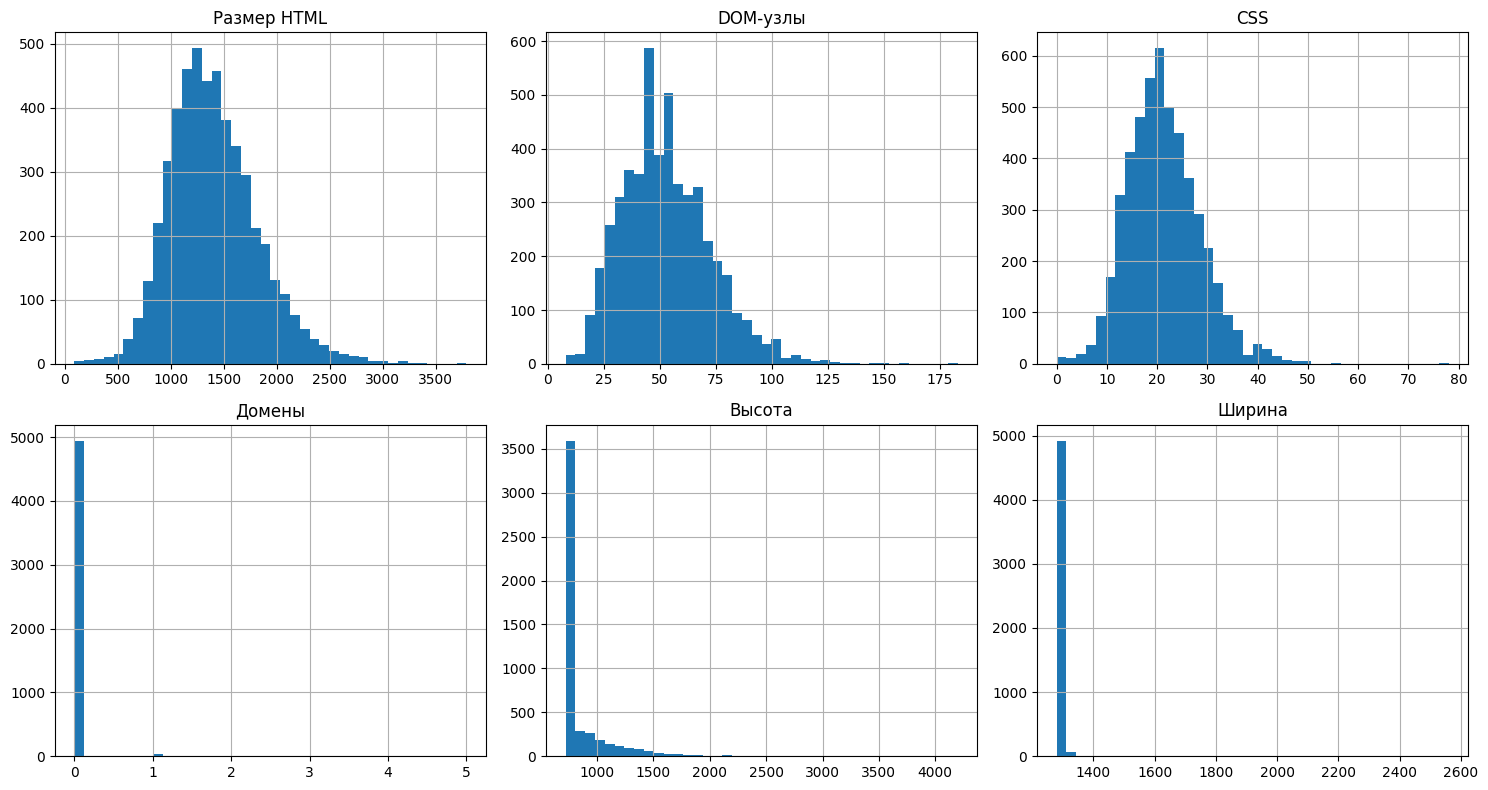

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

ok["html_chars"].hist(ax=axes[0,0], bins=40)
axes[0,0].set_title("Размер HTML")

ok["dom_nodes"].hist(ax=axes[0,1], bins=40)
axes[0,1].set_title("DOM-узлы")

ok["css_decls"].hist(ax=axes[0,2], bins=40)
axes[0,2].set_title("CSS")

ok["n_domains"].hist(ax=axes[1,0], bins=40)
axes[1,0].set_title("Домены")

ok["img_h"].hist(ax=axes[1,1], bins=40)
axes[1,1].set_title("Высота")

ok["img_w"].hist(ax=axes[1,2], bins=40)
axes[1,2].set_title("Ширина")

plt.tight_layout()
plt.show()

## 11. Итоговая сводка

In [11]:
def fmt(x):
    return f"{x:,.1f}" if x is not None else "n/a"

summary = pd.DataFrame([
    ("Количество примеров", f"{TOTAL_EXAMPLES:,}"),
    ("Средний размер HTML", fmt(ok["html_chars"].mean())),
    ("Среднее число DOM-узлов", fmt(ok["dom_nodes"].mean())),
    ("Среднее число CSS правил", fmt(ok["css_decls"].mean())),
    ("Среднее число доменов", fmt(ok["n_domains"].mean()))
], columns=["Метрика", "Значение"])

summary

,Метрика,Значение
0,Количество примеров,"69,953"
1,Средний размер HTML,"1,406.5"
2,Среднее число DOM-узлов,52.9
3,Среднее число CSS правил,21.3
4,Среднее число доменов,0.0
